# PyMC-4 : Reseaux Bayesiens

**Equivalent Infer.NET** : [Infer-4-Bayesian-Networks](../Infer/Infer-4-Bayesian-Networks.ipynb)

**Objectifs** :
- Modeliser un reseau bayesien avec PyMC
- Implementer le reseau Wet Grass (Pluie / Arroseur / Herbe mouillee)
- Comprendre les tables de probabilites conditionnelles (CPT)
- Observer le phenomene d'explaining away
- Verifier la D-separation
- Comparer inference observationnelle vs interventionnelle (do-calculus)

## 1. Le Reseau Wet Grass

### Structure du reseau

```
        Cloudy
       /      \
   Sprinkler   Rain
       \      /
      WetGrass
```

- **Cloudy** : variable racine (P = 0.5)
- **Sprinkler** : depend de Cloudy (P(S|C) = 0.1, P(S|~C) = 0.5)
- **Rain** : depend de Cloudy (P(R|C) = 0.8, P(R|~C) = 0.2)
- **WetGrass** : depend de Sprinkler et Rain (CPT a 2 parents)

### Infer.NET vs PyMC

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| CPT | `Variable.If` / `Variable.IfNot` + `SetTo` | `pt.switch` / `pt.where` |
| Variable booleenne | `Variable.New<bool>()` | `pm.Bernoulli` |
| Observation | `.ObservedValue = true` | `observed=1` |
| D-separation | Analytique (EP) | MCMC (approximation) |

In [1]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt

print(f"PyMC version: {pm.__version__}")

PyMC version: 5.28.5


## 2. Tables de Probabilites Conditionnelles

La CPT de WetGrass a 4 entrees (combinaisons de Sprinkler et Rain) :

In [2]:
# Tables de probabilites conditionnelles (CPT)
# Cloudy
p_cloudy = 0.5

# Sprinkler | Cloudy
p_sprinkler_given_cloudy = {True: 0.1, False: 0.5}  # P(S=1|C)

# Rain | Cloudy
p_rain_given_cloudy = {True: 0.8, False: 0.2}  # P(R=1|C)

# WetGrass | Sprinkler, Rain
p_wetgrass = {
    (True, True): 0.99,
    (True, False): 0.90,
    (False, True): 0.90,
    (False, False): 0.00,
}

print("CPT WetGrass :")
for (s, r), p in p_wetgrass.items():
    print(f"  P(W=1 | S={int(s)}, R={int(r)}) = {p}")

CPT WetGrass :
  P(W=1 | S=1, R=1) = 0.99
  P(W=1 | S=1, R=0) = 0.9
  P(W=1 | S=0, R=1) = 0.9
  P(W=1 | S=0, R=0) = 0.0


## 3. Modele PyMC du Reseau Bayesien

On traduit les CPT avec `pt.switch` (equivalent de `Variable.If`/`Variable.IfNot` en Infer.NET).

In [3]:
# Modele PyMC complet du reseau Wet Grass
# Equivalent Infer.NET : Variable.If / Variable.IfNot + SetTo

with pm.Model() as wet_grass_net:
    # Cloudy (variable racine)
    cloudy = pm.Bernoulli('cloudy', p=p_cloudy)
    
    # Sprinkler | Cloudy
    p_s = pt.switch(pt.eq(cloudy, 1), 0.1, 0.5)
    sprinkler = pm.Bernoulli('sprinkler', p=p_s)
    
    # Rain | Cloudy
    p_r = pt.switch(pt.eq(cloudy, 1), 0.8, 0.2)
    rain = pm.Bernoulli('rain', p=p_r)
    
    # WetGrass | Sprinkler, Rain (CPT a 2 parents)
    p_w = pt.switch(
        pt.eq(sprinkler, 1),
        pt.switch(pt.eq(rain, 1), 0.99, 0.90),  # S=1
        pt.switch(pt.eq(rain, 1), 0.90, 0.00),   # S=0
    )
    wetgrass = pm.Bernoulli('wetgrass', p=p_w)
    
    trace_prior = pm.sample(10000, random_seed=42, return_inferencedata=True)

# Verifications des marginales
cloudy_samples = trace_prior.posterior['cloudy'].values.flatten()
sprinkler_samples = trace_prior.posterior['sprinkler'].values.flatten()
rain_samples = trace_prior.posterior['rain'].values.flatten()
wetgrass_samples = trace_prior.posterior['wetgrass'].values.flatten()

print("=== Marginales (sans observation) ===")
print(f"P(Cloudy=1) = {cloudy_samples.mean():.3f} (theorie: 0.500)")
print(f"P(Sprinkler=1) = {sprinkler_samples.mean():.3f} (theorie: 0.300)")
print(f"P(Rain=1) = {rain_samples.mean():.3f} (theorie: 0.500)")
print(f"P(WetGrass=1) = {wetgrass_samples.mean():.3f}")

Multiprocess sampling (4 chains in 4 jobs)


BinaryGibbsMetropolis: [cloudy, sprinkler, rain, wetgrass]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 31 seconds.


=== Marginales (sans observation) ===
P(Cloudy=1) = 0.494 (theorie: 0.500)
P(Sprinkler=1) = 0.301 (theorie: 0.300)
P(Rain=1) = 0.493 (theorie: 0.500)
P(WetGrass=1) = 0.643


## 4. Inference Conditionnelle : Herbe Mouillee Observee

On observe que l'herbe est mouillee (WetGrass = True). Qu'en deduit-on sur la pluie et l'arroseur ?

In [4]:
# Inference avec observation WetGrass = True
with pm.Model() as wet_grass_obs:
    cloudy = pm.Bernoulli('cloudy', p=p_cloudy)
    
    p_s = pt.switch(pt.eq(cloudy, 1), 0.1, 0.5)
    sprinkler = pm.Bernoulli('sprinkler', p=p_s)
    
    p_r = pt.switch(pt.eq(cloudy, 1), 0.8, 0.2)
    rain = pm.Bernoulli('rain', p=p_r)
    
    p_w = pt.switch(
        pt.eq(sprinkler, 1),
        pt.switch(pt.eq(rain, 1), 0.99, 0.90),
        pt.switch(pt.eq(rain, 1), 0.90, 0.00),
    )
    wetgrass = pm.Bernoulli('wetgrass', p=p_w, observed=1)
    
    trace_obs = pm.sample(10000, random_seed=42, return_inferencedata=True)

s_obs = trace_obs.posterior['sprinkler'].values.flatten()
r_obs = trace_obs.posterior['rain'].values.flatten()
c_obs = trace_obs.posterior['cloudy'].values.flatten()

print("=== Posterior (WetGrass = True observe) ===")
print(f"P(Sprinkler=1 | WetGrass=1) = {s_obs.mean():.3f} (theorie: ~0.43)")
print(f"P(Rain=1 | WetGrass=1) = {r_obs.mean():.3f} (theorie: ~0.71)")
print(f"P(Cloudy=1 | WetGrass=1) = {c_obs.mean():.3f}")

Multiprocess sampling (4 chains in 4 jobs)


BinaryGibbsMetropolis: [cloudy, sprinkler, rain]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 37 seconds.


=== Posterior (WetGrass = True observe) ===
P(Sprinkler=1 | WetGrass=1) = 0.429 (theorie: ~0.43)
P(Rain=1 | WetGrass=1) = 0.707 (theorie: ~0.71)
P(Cloudy=1 | WetGrass=1) = 0.575


## 5. Explaining Away

Le phenomene d'**explaining away** : quand on sait qu'il pleut, la probabilite que l'arroseur soit en marche diminue, car la pluie "explique" deja l'herbe mouillee.

In [5]:
# Explaining Away : observer la pluie EN PLUS de l'herbe mouillee
with pm.Model() as wet_grass_explaining:
    cloudy = pm.Bernoulli('cloudy', p=p_cloudy)
    
    p_s = pt.switch(pt.eq(cloudy, 1), 0.1, 0.5)
    sprinkler = pm.Bernoulli('sprinkler', p=p_s)
    
    p_r = pt.switch(pt.eq(cloudy, 1), 0.8, 0.2)
    rain = pm.Bernoulli('rain', p=p_r, observed=1)  # Rain = True observe
    
    p_w = pt.switch(
        pt.eq(sprinkler, 1),
        0.99,  # S=1, R=1
        0.90,  # S=0, R=1
    )
    wetgrass = pm.Bernoulli('wetgrass', p=p_w, observed=1)
    
    trace_expl = pm.sample(10000, random_seed=42, return_inferencedata=True)

s_expl = trace_expl.posterior['sprinkler'].values.flatten()

print("=== Explaining Away ===")
print(f"P(Sprinkler=1 | WetGrass=1) = {s_obs.mean():.3f}")
print(f"P(Sprinkler=1 | WetGrass=1, Rain=1) = {s_expl.mean():.3f}")
print()
print("La probabilite de l'arroseur diminue car la pluie explique deja l'herbe mouillee.")
print("C'est le phenomene d'explaining away : les causes competitives se supplantent.")

Multiprocess sampling (4 chains in 4 jobs)


BinaryGibbsMetropolis: [cloudy, sprinkler]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 31 seconds.


=== Explaining Away ===
P(Sprinkler=1 | WetGrass=1) = 0.429
P(Sprinkler=1 | WetGrass=1, Rain=1) = 0.194

La probabilite de l'arroseur diminue car la pluie explique deja l'herbe mouillee.
C'est le phenomene d'explaining away : les causes competitives se supplantent.


## 6. Visualisation des Effets

Comparaison des probabilites conditionnelles dans differents scenarios.

Multiprocess sampling (4 chains in 4 jobs)


BinaryGibbsMetropolis: [cloudy, rain]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 38 seconds.


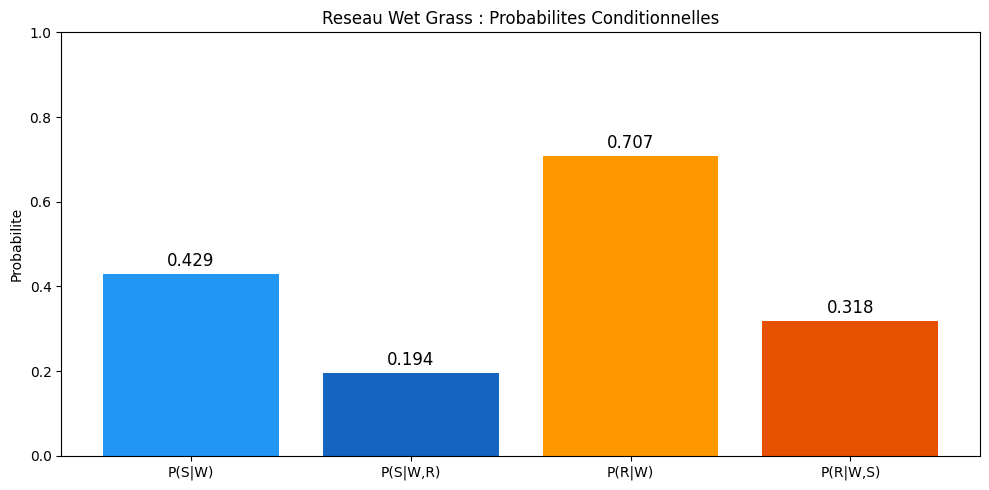

In [6]:
# Scenario supplementaire : Sprinkler observe + WetGrass observe
with pm.Model() as wet_grass_sprinkler_obs:
    cloudy = pm.Bernoulli('cloudy', p=p_cloudy)
    
    p_s = pt.switch(pt.eq(cloudy, 1), 0.1, 0.5)
    sprinkler = pm.Bernoulli('sprinkler', p=p_s, observed=1)
    
    p_r = pt.switch(pt.eq(cloudy, 1), 0.8, 0.2)
    rain = pm.Bernoulli('rain', p=p_r)
    
    p_w = pt.switch(
        pt.eq(rain, 1),
        0.99,  # S=1, R=1
        0.90,  # S=1, R=0
    )
    wetgrass = pm.Bernoulli('wetgrass', p=p_w, observed=1)
    
    trace_sobs = pm.sample(10000, random_seed=42, return_inferencedata=True)

r_sobs = trace_sobs.posterior['rain'].values.flatten()

# Visualisation
scenarios = ['P(S|W)', 'P(S|W,R)', 'P(R|W)', 'P(R|W,S)']
values = [s_obs.mean(), s_expl.mean(), r_obs.mean(), r_sobs.mean()]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
colors = ['#2196F3', '#1565C0', '#FF9800', '#E65100']
bars = ax.bar(scenarios, values, color=colors)
ax.set_ylim(0, 1)
ax.set_ylabel('Probabilite')
ax.set_title('Reseau Wet Grass : Probabilites Conditionnelles')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontsize=12)
plt.tight_layout()
plt.show()

## 7. D-Separation

La **D-separation** determine si deux variables sont independantes conditionnellement a un ensemble de variables observees.

### Structures du reseau Wet Grass

1. **Fourche** (Fork) : Sprinkler <-- Cloudy --> Rain
   - Sans observation : S et R sont dependants (via C)
   - En observant C : S et R deviennent independants (D-separes)

2. **Collision** (Collider) : Sprinkler --> WetGrass <-- Rain
   - Sans observation : S et R sont independants
   - En observant W : S et R deviennent dependants (explaining away)

In [7]:
# Verification de la D-separation par correlation
from scipy.stats import pearsonr

# 1. Fourche (Fork) : S <-- C --> R
# Sans observation : S et R sont-ils dependants ?
corr_fork, _ = pearsonr(sprinkler_samples, rain_samples)
print(f"=== D-Separation : Fourche (S <-- C --> R) ===")
print(f"Correlation S-R sans observation : {corr_fork:.4f}")
print(f"-> S et R sont dependants (partagent la cause C)")
print()

# 2. Simulation Monte Carlo pour le collider
np.random.seed(42)
n = 50000
c_samp = np.random.binomial(1, 0.5, n)
s_samp = np.array([np.random.binomial(1, 0.1 if c else 0.5) for c in c_samp])
r_samp = np.array([np.random.binomial(1, 0.8 if c else 0.2) for c in c_samp])
w_samp = np.array([
    np.random.binomial(1, 0.99 if s and r else 0.90 if s or r else 0.0)
    for s, r in zip(s_samp.astype(bool), r_samp.astype(bool))
])

# Conditionner sur W=1 : explaining away
mask_w1 = w_samp.astype(bool)
if mask_w1.sum() > 100:
    corr_w1, _ = pearsonr(s_samp[mask_w1], r_samp[mask_w1])
    print(f"=== D-Separation : Collider (S --> W <-- R) ===")
    print(f"Correlation S-R sachant W=1 : {corr_w1:.4f}")
    print(f"-> Explaining away : S et R deviennent negativement correles")
else:
    print("Pas assez d'echantillons W=1 pour la correlation")

=== D-Separation : Fourche (S <-- C --> R) ===
Correlation S-R sans observation : -0.2630
-> S et R sont dependants (partagent la cause C)



=== D-Separation : Collider (S --> W <-- R) ===
Correlation S-R sachant W=1 : -0.7400
-> Explaining away : S et R deviennent negativement correles


## 8. Inference Observationnelle vs Interventionnelle

La distinction entre **voir** (observation) et **faire** (intervention) est fondamentale en causalite.

- **P(Cloudy | Rain=True)** : observationnelle. Si on voit qu'il pleut, c'est probablement nuageux.
- **P(Cloudy | do(Rain=True))** : interventionnelle. Si on FAIT pleuvoir, cela n'affecte pas les nuages.

Le do-calculus de Pearl : `do(X=x)` coupe les fleches entrantes vers X.

In [8]:
# Observationnel : P(Cloudy | Rain=True)
with pm.Model() as obs_rain:
    cloudy = pm.Bernoulli('cloudy', p=0.5)
    p_s = pt.switch(pt.eq(cloudy, 1), 0.1, 0.5)
    sprinkler = pm.Bernoulli('sprinkler', p=p_s)
    p_r = pt.switch(pt.eq(cloudy, 1), 0.8, 0.2)
    rain = pm.Bernoulli('rain', p=p_r, observed=1)
    p_w = pt.switch(
        pt.eq(sprinkler, 1),
        pt.switch(pt.eq(rain, 1), 0.99, 0.90),
        pt.switch(pt.eq(rain, 1), 0.90, 0.00),
    )
    wetgrass = pm.Bernoulli('wetgrass', p=p_w)
    
    trace_or = pm.sample(10000, random_seed=42, return_inferencedata=True)

c_or = trace_or.posterior['cloudy'].values.flatten()
print(f"=== Observationnel vs Interventionnel ===")
print(f"P(Cloudy=1 | Rain=1) = {c_or.mean():.3f} (observationnel, theorie: 0.800)")
print()

# Interventionnel : P(Cloudy | do(Rain=True))
# Le do() coupe le lien Cloudy -> Rain. Rain est fixe a 1.
with pm.Model() as do_rain:
    cloudy = pm.Bernoulli('cloudy', p=0.5)
    p_s = pt.switch(pt.eq(cloudy, 1), 0.1, 0.5)
    sprinkler = pm.Bernoulli('sprinkler', p=p_s)
    # do(Rain=True) : Rain est fixe, pas un noeud aleatoire
    p_w = pt.switch(
        pt.eq(sprinkler, 1),
        0.99,  # S=1, R=1 (R est toujours 1)
        0.90,  # S=0, R=1
    )
    wetgrass = pm.Bernoulli('wetgrass', p=p_w)
    
    trace_do = pm.sample(10000, random_seed=42, return_inferencedata=True)

c_do = trace_do.posterior['cloudy'].values.flatten()
print(f"P(Cloudy=1 | do(Rain=1)) = {c_do.mean():.3f} (interventionnel, theorie: 0.500)")
print()
print("Difference cle :")
print(f"  Observer la pluie nous informe sur les nuages ({c_or.mean():.3f})")
print(f"  Provoquer la pluie n'affecte pas les nuages ({c_do.mean():.3f})")
print(f"  Voir != Faire (Pearl, 2000)")

Multiprocess sampling (4 chains in 4 jobs)


BinaryGibbsMetropolis: [cloudy, sprinkler, wetgrass]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 33 seconds.


Multiprocess sampling (4 chains in 4 jobs)


BinaryGibbsMetropolis: [cloudy, sprinkler, wetgrass]


=== Observationnel vs Interventionnel ===
P(Cloudy=1 | Rain=1) = 0.800 (observationnel, theorie: 0.800)



C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 31 seconds.


P(Cloudy=1 | do(Rain=1)) = 0.500 (interventionnel, theorie: 0.500)

Difference cle :
  Observer la pluie nous informe sur les nuages (0.800)
  Provoquer la pluie n'affecte pas les nuages (0.500)
  Voir != Faire (Pearl, 2000)


## 9. Comparaison Infer.NET vs PyMC pour les Reseaux Bayesiens

| Aspect | Infer.NET | PyMC |
|--------|-----------|------|
| CPT | `Variable.If`/`IfNot` + `SetTo` | `pt.switch`/`pt.where` |
| Variables discretes | `Variable.Discrete` | `pm.Bernoulli`/`pm.Categorical` |
| do-calculus | Modification manuelle du modele | Recreer le modele sans lien causal |
| Performance | EP exact pour discrets | MCMC (approximation, plus lent) |
| D-separation | Analytique | Verification empirique (correlation) |
| Flexibilite | Modeles compatibles EP | Tres general |

## Exercice : Diagnostic Medical

Modelisez un reseau bayesien pour un diagnostic medical simplifie :

```
    Cold --> Fatigue
    Flu  --> Fatigue --> Fever
```

- P(Cold) = 0.05, P(Flu) = 0.02
- P(Fatigue=1 | Cold, Flu) : C=1,F=1 -> 0.95, C=1,F=0 -> 0.7, C=0,F=1 -> 0.9, C=0,F=0 -> 0.1
- P(Fever=1 | Fatigue=1) = 0.85, P(Fever=1 | Fatigue=0) = 0.10

**Questions** :
1. Calculer P(Fever=1) (marginal)
2. Calculer P(Cold=1 | Fever=1) et P(Flu=1 | Fever=1)
3. Observer le phenomene d'explaining away entre Cold et Flu

**Indices** :
- Utiliser `pt.switch` imbriques pour la CPT de Fatigue
- Observer Fever=1 et comparer P(Cold=1 | Fever=1) vs P(Cold=1 | Fever=1, Flu=1)

In [9]:
# TODO etudiant : implementer le reseau bayesien medical
# P(Fever=1) = ?
# P(Cold=1 | Fever=1) = ?
# P(Flu=1 | Fever=1) = ?

print("Exercice a completer")

Exercice a completer
